# Employee Attrition Prediction
## A Full ML Classification Pipeline

**Course: Data science and Machine Learning for Engineering Applications**  
**Dataset: IBM HR Analytics — Employee Attrition**

---

### How This Session Works

This notebook contains a **pre-built classification pipeline**. The code is already written - your job is to **think, decide, and steer it** at every critical step.

At key moments you'll encounter one of two checkpoint types:

| Type | Name | What to do |
|------|------|------------|
| **VOTE** | Open question | Analyze the output → answer on **wayground** → we discuss before running the next cell |
| **PARAM** | Parameter choice | Vote on a value → we run and see the consequences together |

**No coding required. 100% thinking required.**

---

### The Pipeline

```
Raw Data  ──►  EDA  ──►  Clean  ──►  Split  ──►  Encode  ──►  Scale
                                                                    │
                            Evaluate  ◄──  CV  ◄──  PCA  ◄──  Statsmodels
```

---

### The Business Problem

IBM has shared data on **1,470 employees**. Each row is one employee, described by 35 features ranging from age and salary to job role and work-life balance rating.

> **Goal:** Predict which employees are likely to leave the company.

**Why it matters:** Replacing an employee costs an estimated **20–200% of their annual salary**. Early detection enables targeted retention strategies.

**Target variable:** `Attrition` → `Yes` (employee left) / `No` (employee stayed)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay)
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)

print("All libraries loaded successfully")


All libraries loaded successfully


---
## Section 1 — Load & Explore

In [2]:
# Dataset: IBM HR Analytics Employee Attrition
URL = "https://github.com/IBM/employee-attrition-aif360/blob/master/data/emp_attrition.csv?raw=true"

try:
    df = pd.read_csv(URL)
    print(f"Dataset loaded from URL")
except Exception as e:
    print(f"URL failed ({e}). Please download the dataset manually from:")
    print("   https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset")
    print("   and load it with: df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')")
    raise

print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head(3)


Dataset loaded from URL
Shape: 1470 rows × 35 columns


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0


In [3]:
# Overview: dtypes, unique values, sample values
info_df = pd.DataFrame({
    'dtype': df.dtypes,
    'n_unique': df.nunique(),
    'null_count': df.isnull().sum(),
    'sample_values': [str(df[col].unique()[:3].tolist()) for col in df.columns]
})
info_df


,dtype,n_unique,null_count,sample_values
Age,int64,43,0,"[41, 49, 37]"
Attrition,str,2,0,"['Yes', 'No']"
BusinessTravel,str,3,0,"['Travel_Rarely', 'Travel_Frequently', 'Non-Tr..."
DailyRate,int64,886,0,"[1102, 279, 1373]"
Department,str,3,0,"['Sales', 'Research & Development', 'Human Res..."
DistanceFromHome,int64,29,0,"[1, 8, 2]"
Education,int64,5,0,"[2, 1, 4]"
EducationField,str,6,0,"['Life Sciences', 'Other', 'Medical']"
EmployeeCount,int64,1,0,[1]
EmployeeNumber,int64,1470,0,"[1, 2, 4]"


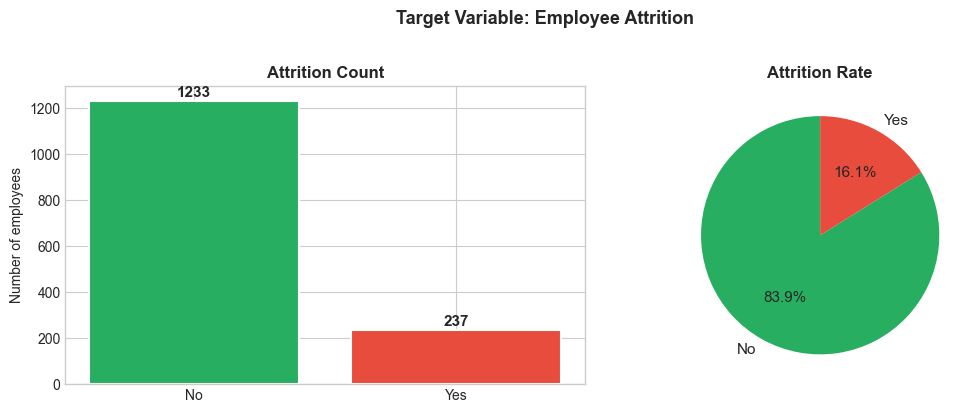


Class imbalance: only 16.1% of employees left.
   This will heavily influence our choice of evaluation metrics later.


In [4]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

counts = df['Attrition'].value_counts()
colors = ['#27ae60','#e74c3c']

axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Attrition Count', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of employees')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 15, str(v), ha='center', fontsize=11, fontweight='bold')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Attrition Rate', fontsize=12, fontweight='bold')

plt.suptitle('Target Variable: Employee Attrition', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nClass imbalance: only {counts['Yes']/len(df)*100:.1f}% of employees left.")
print("   This will heavily influence our choice of evaluation metrics later.")


---
## VOTE 1 — Spot the Useless Columns

Look at the column overview above (especially `n_unique`).

**Question: Which columns carry absolutely zero predictive information - and should be dropped immediately?**




In [7]:
useless = [] # Insert here the right column names
df = df.drop(columns=useless)

print(f"Dropped {len(useless)} useless columns: {useless}")
print(f"   New shape: {df.shape}")

Dropped 0 useless columns: []
   New shape: (1470, 31)


---
## Section 2 — Missing Data

In [18]:
# ─── SIMULATING REAL-WORLD MISSING DATA ─────────────────────────────────────
# The IBM dataset has no missing values — we introduce them here
# in a realistic way so we can practice imputation strategies.
# ─────────────────────────────────────────────────────────────────────────────

np.random.seed(42)

cols_to_corrupt = {
    'Age':            0.06,   # ~6% missing — numeric, roughly symmetric
    'MonthlyIncome':  0.05,   # ~5% missing — numeric, RIGHT-SKEWED
    'JobSatisfaction':0.07,   # ~7% missing — ordinal integer (1–4)
    'EducationField': 0.04,   # ~4% missing — categorical string
}

df_dirty = df.copy()
for col, rate in cols_to_corrupt.items():
    mask = np.random.rand(len(df_dirty)) < rate
    df_dirty.loc[mask, col] = np.nan

print("Missing values introduced:")
mv = df_dirty.isnull().sum()
print(mv[mv > 0].to_string())


Missing values introduced:
Age                 94
EducationField      53
JobSatisfaction    113
MonthlyIncome       75


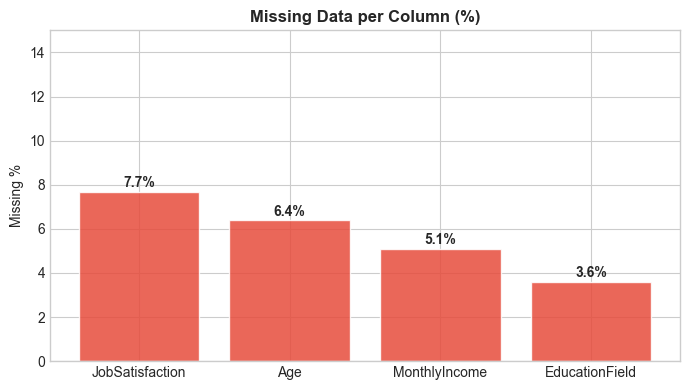

In [19]:
# Visualize missing values

# Bar chart: % missing per column
mv_pct = (df_dirty.isnull().sum() / len(df_dirty) * 100)
mv_pct = mv_pct[mv_pct > 0].sort_values(ascending=False)

fig, axes = plt.subplots(1, 1, figsize=(7, 4))


bars = axes.bar(mv_pct.index, mv_pct.values, color='#e74c3c', alpha=0.85, edgecolor='white')
axes.set_title('Missing Data per Column (%)', fontweight='bold')
axes.set_ylabel('Missing %')
axes.set_ylim(0, 15)
for bar, val in zip(bars, mv_pct.values):
    axes.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
              f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()


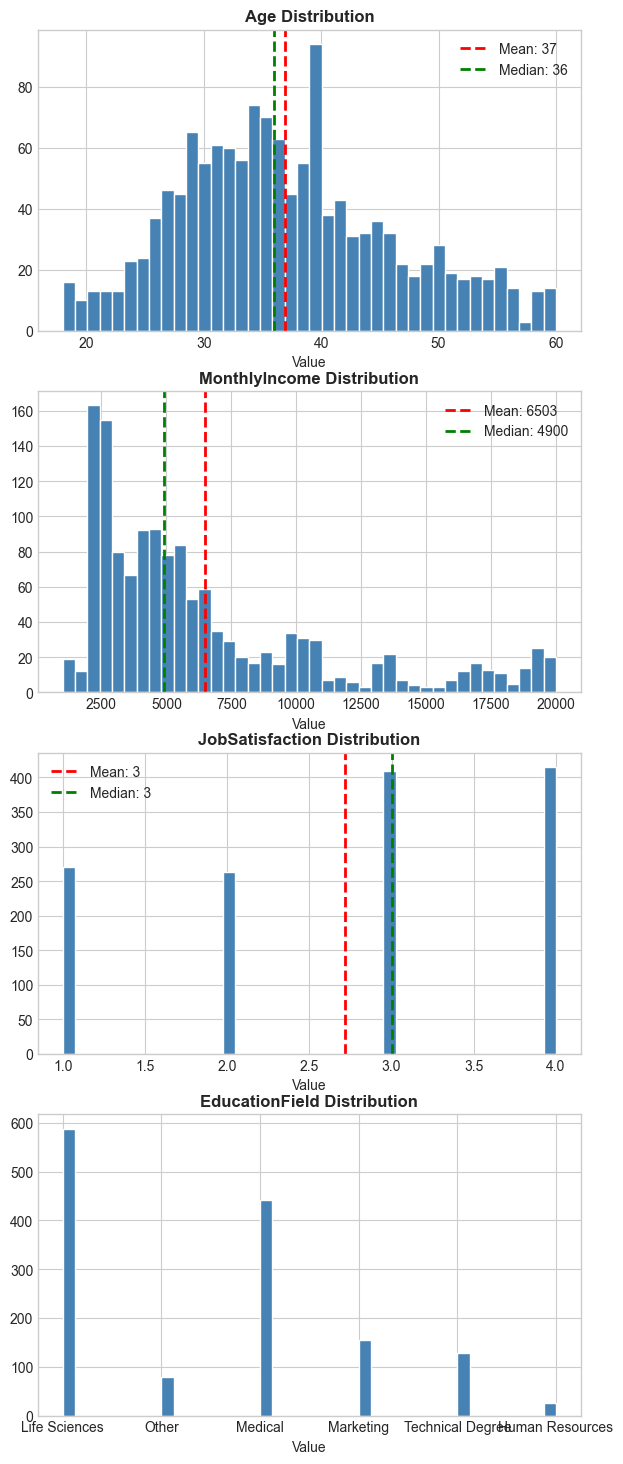

In [20]:
# Distribution of MonthlyIncome — illustrate skew
fig, axes = plt.subplots(4, 1, figsize=(7, 18))

for i, columns in enumerate(['Age', 'MonthlyIncome', 'JobSatisfaction', 'EducationField']):
    axes[i].hist(df_dirty[columns].dropna(), bins=40, color='steelblue', edgecolor='white')

    if df_dirty[columns].dtype in ['int64', 'float64']:
        axes[i].axvline(df_dirty[columns].mean(), color='red', linestyle='--',
                        linewidth=2, label=f"Mean: {df_dirty[columns].mean():.0f}")
        axes[i].axvline(df_dirty[columns].median(), color='green', linestyle='--',
                    linewidth=2, label=f"Median: {df_dirty[columns].median():.0f}")
    axes[i].set_title(f'{columns} Distribution', fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].legend()


---
## PARAM 1 — Imputation Strategy

We have 4 columns with missing values, each with a **different data type**:

| Column | Type | Distribution | Missing % |
|--------|------|-------------|-----------|
| `Age` | Continuous numeric | Roughly symmetric | ~6% |
| `MonthlyIncome` | Continuous numeric | **Right-skewed** (look at the chart!) | ~5% |
| `JobSatisfaction` | Ordinal integer (1–4) | Discrete | ~7% |
| `EducationField` | Categorical string | N/A | ~4% |

**Question:** What strategy should we use for each?

- **Mean** → good for symmetric distributions. Sensitive to outliers.  
- **Median** → robust to skew and outliers. Better for income-like variables.  
- **Mode** → the only sensible choice for categorical values.

> **Vote**

In [25]:
# ─── SET IMPUTATION STRATEGY — instructor updates these after PARAM 1 ────

IMPUTE_AGE             = ''    # Roughly symmetric numeric 
IMPUTE_MONTHLY_INCOME  = ''    # 'income is RIGHT-SKEWED
IMPUTE_JOB_SATISFACTION= ''    # ordinal integer
IMPUTE_EDUCATION_FIELD = ''      # categorical: no other option

# ─────────────────────────────────────────────────────────────────────────────
df_clean = df_dirty.copy()

strategies = {
    'Age':             IMPUTE_AGE,
    'MonthlyIncome':   IMPUTE_MONTHLY_INCOME,
    'JobSatisfaction': IMPUTE_JOB_SATISFACTION,
}

for col, strategy in strategies.items():
    fill = df_clean[col].mean() if strategy == 'mean' else df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(fill)
    print(f"  {col:<22} → {strategy} = {fill:.2f}")

fill_cat = df_clean['EducationField'].mode()[0]
df_clean['EducationField'] = df_clean['EducationField'].fillna(fill_cat)
print(f"  EducationField         → mode  = '{fill_cat}'")

print(f"\nMissing values remaining: {df_clean.isnull().sum().sum()}")

  Age                    →  = 36.00
  MonthlyIncome          →  = 4900.00
  JobSatisfaction        →  = 3.00
  EducationField         → mode  = 'Life Sciences'

Missing values remaining: 0


---
## Section 3 — Train / Test Split

## 🗳️ VOTE 3 — The Most Common Pipeline Mistake

Before we split, consider this scenario:

> *A team applies One-Hot Encoding and StandardScaler on the entire dataset
> (fit + transform on all 1470 rows), then splits into train/test.*

**Go to Quizizz and answer the 3 questions before we proceed.**

In [26]:
# Encode target before splitting
df_clean['Attrition'] = df_clean['Attrition'].map({'Yes': 1, 'No': 0})

X = df_clean.drop(columns=['Attrition'])
y = df_clean['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y          # preserves the 84/16 class ratio in both splits
)

print(f"Training set : {X_train.shape[0]:4d} samples  —  attrition rate: {y_train.mean()*100:.1f}%")
print(f"Test set     : {X_test.shape[0]:4d} samples  —  attrition rate: {y_test.mean()*100:.1f}%")
print(f"\nStratified split: class ratio preserved in both sets.")
print(f"   Features: {X_train.shape[1]} (including categorical — will be encoded next)")

Training set : 1176 samples  —  attrition rate: 16.2%
Test set     :  294 samples  —  attrition rate: 16.0%

Stratified split: class ratio preserved in both sets.
   Features: 30 (including categorical — will be encoded next)


---
## Section 4 — Categorical Encoding

In [ ]:
# Identify what types of columns we're working with in the training set
print("Object (categorical) columns:")
obj_cols = X_train.select_dtypes(include='object').columns.tolist()
for col in obj_cols:
    print(f"  {col} ------------— {X_train[col].nunique()} unique values: {X_train[col].unique().tolist()}")

print("\nNumeric columns (sample):")
num_cols = X_train.select_dtypes(include='number').columns.tolist()
print(f"  {num_cols[:8]} ...")

Object (categorical) columns:
  BusinessTravel ------------— 3 unique values: ['Travel_Rarely', 'Travel_Frequently', 'Non-Travel']
  Department ------------— 3 unique values: ['Sales', 'Research & Development', 'Human Resources']
  EducationField ------------— 6 unique values: ['Life Sciences', 'Technical Degree', 'Marketing', 'Medical', 'Other', 'Human Resources']
  Gender ------------— 2 unique values: ['Female', 'Male']
  JobRole ------------— 9 unique values: ['Manager', 'Laboratory Technician', 'Sales Representative', 'Research Scientist', 'Manufacturing Director', 'Sales Executive', 'Research Director', 'Healthcare Representative', 'Human Resources']
  MaritalStatus ------------— 3 unique values: ['Divorced', 'Married', 'Single']
  OverTime ------------— 2 unique values: ['No', 'Yes']

Numeric columns (sample):
  ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel'] ...


---
## VOTE 2 — One-Hot Encoding

Look at the categorical columns in the training set above.

**Questions:**
1. Which encoding strategy should we apply to our categorical columns?
2. Why is encoding Gender as Male=1 / Female=0 safe, but encoding JobRole as an integer (0, 1, 2, 3...) would be wrong?


> **Go to Quizizz and answer before we run the next cell.**

In [31]:
from sklearn.preprocessing import OneHotEncoder

# ── Separate columns by encoding strategy ────────────────────────────────────
binary_cols = ['Gender', 'OverTime']          # only 2 categories → map to 0/1
cat_cols    = [c for c in X_train.select_dtypes(include='object').columns
               if c not in binary_cols]
num_cols    = X_train.select_dtypes(exclude='object').columns.tolist()

# ── Binary encoding — no OHE needed, just a direct map ───────────────────────
binary_maps = {
    'Gender':   {'Male': 1, 'Female': 0},
    'OverTime':  {'Yes': 1, 'No': 0},
}

X_train_bin = X_train[binary_cols].replace(binary_maps)
X_test_bin  = X_test[binary_cols].replace(binary_maps)

# ── OHE for true multi-category columns ──────────────────────────────────────
ohe = OneHotEncoder(
    drop='first',
    sparse_output=False,
    handle_unknown='ignore'
)
ohe.fit(X_train[cat_cols])

train_ohe = pd.DataFrame(
    ohe.transform(X_train[cat_cols]),
    columns=ohe.get_feature_names_out(cat_cols),
    index=X_train.index
)
test_ohe = pd.DataFrame(
    ohe.transform(X_test[cat_cols]),
    columns=ohe.get_feature_names_out(cat_cols),
    index=X_test.index
)

# ── Recombine all three parts ─────────────────────────────────────────────────
X_train_enc = pd.concat([X_train[num_cols], X_train_bin, train_ohe], axis=1)
X_test_enc  = pd.concat([X_test[num_cols],  X_test_bin,  test_ohe],  axis=1)

print(f"✅ Encoding complete")
print(f"   Numeric columns   : {len(num_cols)}")
print(f"   Binary columns    : {binary_cols}")
print(f"   OHE columns       : {cat_cols}")
print(f"   Final shape       : {X_train_enc.shape}")

✅ Encoding complete
   Numeric columns   : 23
   Binary columns    : ['Gender', 'OverTime']
   OHE columns       : ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']
   Final shape       : (1176, 44)


---
## Section 5 — Standardization

In [76]:
# StandardScaler: subtract mean, divide by std → mean=0, std=1
# fit() computes mean & std → on TRAIN only
# transform() applies them → on BOTH train and test

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_enc)
X_test_scaled  = scaler.transform(X_test_enc)          # ← .transform() only, NOT .fit_transform()

# Wrap back into DataFrames to keep column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_enc.columns, index=X_train_enc.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test_enc.columns,  index=X_test_enc.index)

print("After StandardScaler:")
print(f"  Train — mean: {X_train_scaled.mean().mean():.8f}  (approx 0)")
print(f"  Train — std : {X_train_scaled.std().mean():.6f}   (approx 1)")
print(f"\n  Test  — mean: {X_test_scaled.mean().mean():.6f}")
print(f"  Test  — std : {X_test_scaled.std().mean():.6f}")
print("\n  The test set is NOT centered at 0 — this is EXPECTED.")
print("    We only fitted the scaler on train, so the test retains its own natural offset.")

After StandardScaler:
  Train — mean: 0.00000000  (approx 0)
  Train — std : 1.000425   (approx 1)

  Test  — mean: -0.008219
  Test  — std : 1.002206

  The test set is NOT centered at 0 — this is EXPECTED.
    We only fitted the scaler on train, so the test retains its own natural offset.


---
## Section 6 — Feature Analysis & Selection

Before PCA, we tackle two related problems:

1. **Remove redundant features** — pairs with very high correlation carry duplicate information. Keeping both wastes capacity and inflates variance.
2. **Check residual multicollinearity** — VIF measures how well each feature is still linearly predicted by the others after the correlation filter.
3. **Explore expected directions** — a Logit model shows the *direction* of each feature's influence. Useful for sanity-checking results, **not for selecting features**.

> We work on the **training set only** (`X_train_scaled`). The test set is invisible until Section 9.

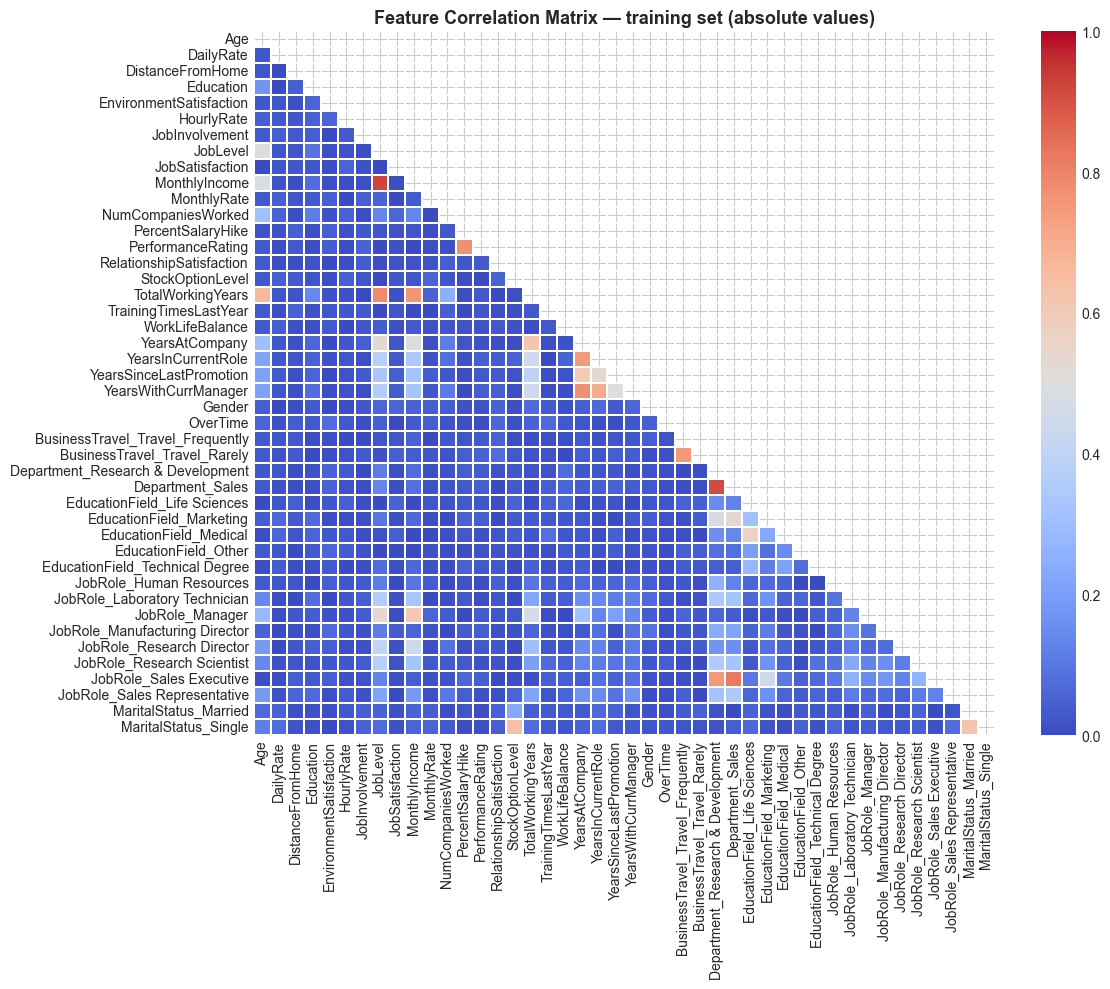

Top 10 most correlated pairs:
JobLevel                           MonthlyIncome                  0.924
Department_Research & Development  Department_Sales               0.912
Department_Sales                   JobRole_Sales Executive        0.821
JobLevel                           TotalWorkingYears              0.785
YearsAtCompany                     YearsWithCurrManager           0.776
PercentSalaryHike                  PerformanceRating              0.774
MonthlyIncome                      TotalWorkingYears              0.765
BusinessTravel_Travel_Frequently   BusinessTravel_Travel_Rarely   0.750
Department_Research & Development  JobRole_Sales Executive        0.749
YearsAtCompany                     YearsInCurrentRole             0.747
YearsInCurrentRole                 YearsWithCurrManager           0.707
Age                                TotalWorkingYears              0.666
StockOptionLevel                   MaritalStatus_Single           0.638
MaritalStatus_Married             

In [77]:
# Correlation matrix — computed on training data only
corr_matrix = X_train_scaled.corr().abs()

# Visualize lower triangle
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', vmin=0, vmax=1,
            annot=False, linewidths=0.3, ax=ax)
ax.set_title('Feature Correlation Matrix — training set (absolute values)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# Show top correlated pairs
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
pairs = upper_tri.stack().sort_values(ascending=False)
print("Top 10 most correlated pairs:")
print(pairs.head(15).to_string())

Some features are trivially highly correlated — for example, `YearsAtCompany` is the sum of `YearsWithCurrManager` and `YearsInCurrentRole`, however dropping either of the two would lose information. We need a smarter solution.

**The problem:** `YearsWithCurrManager` and `YearsInCurrentRole` are highly
correlated with `YearsAtCompany`. Dropping them would lose information.
Keeping them as-is introduces redundancy.

**The solution:** extract the *delta* — the part that is actually meaningful.

| New feature | Formula | What it captures |
|---|---|---|
| `YearsWithSameManager` | `YearsAtCompany − YearsWithCurrManager` | Managerial stability — high turnover is a known attrition driver |
| `YearsInOtherRoles` | `YearsAtCompany − YearsInCurrentRole` | Career mobility within the company |

We then drop the originals — the delta contains all the information we need,
without the redundancy.

In [78]:
X_train_scaled['YearsWithSameManager'] = (
    X_train_scaled['YearsAtCompany'] - X_train_scaled['YearsWithCurrManager']
)
X_train_scaled['YearsInOtherRoles'] = (
    X_train_scaled['YearsAtCompany'] - X_train_scaled['YearsInCurrentRole']
)
X_test_scaled['YearsWithSameManager'] = (
    X_test_scaled['YearsAtCompany'] - X_test_scaled['YearsWithCurrManager']
)
X_test_scaled['YearsInOtherRoles'] = (
    X_test_scaled['YearsAtCompany'] - X_test_scaled['YearsInCurrentRole']
)

# Drop the originals — the delta contains all the information we need
X_train_scaled = X_train_scaled.drop(columns=['YearsWithCurrManager', 'YearsInCurrentRole'])
X_test_scaled  = X_test_scaled.drop(columns=['YearsWithCurrManager', 'YearsInCurrentRole'])


---
## PARAM 2 — Correlation Threshold

| Threshold | Effect |
|-----------|--------|
| **0.9** | Very lenient — only removes near-perfect duplicates |
| **0.8** | Moderate — removes strongly redundant features |
| **0.5** | Aggressive — removes moderately correlated pairs |

> **Vote and we will set `CORR_THRESHOLD` below.**

([<matplotlib.axis.XTick at 0x13a92fd70>,
 [Text(0.5, 0, '0.5'),
  Text(0.6, 0, '0.6'),
  Text(0.7, 0, '0.7'),
  Text(0.8, 0, '0.8'),
  Text(0.9, 0, '0.9'),
  Text(1.0, 0, '1.0')])

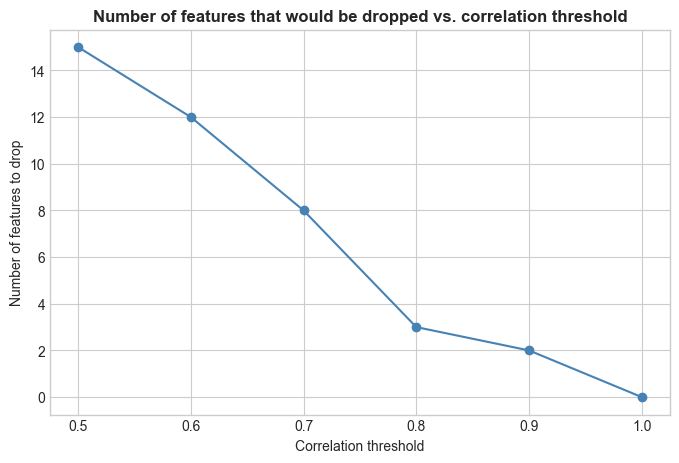

In [79]:
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
size_to_drop=[]
thresholds = np.linspace(0.5, 1, 6)
for CORR_THRESHOLD in thresholds:
    to_drop = [col for col in upper_tri.columns if any(upper_tri[col] > CORR_THRESHOLD)]
    size_to_drop.append(len(to_drop))

plt.figure(figsize=(8, 5))
plt.plot(thresholds, size_to_drop, marker='o', color='steelblue')
plt.title('Number of features that would be dropped vs. correlation threshold', fontweight='bold')
plt.xlabel('Correlation threshold')
plt.ylabel('Number of features to drop')
plt.xticks(thresholds)

In [ ]:
# ─── SET CORRELATION THRESHOLD — instructor updates after PARAM 2 ─────────────

CORR_THRESHOLD = 1   # <── CHANGE THIS

# ─────────────────────────────────────────────────────────────────────────────
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper_tri.columns if any(upper_tri[col] > CORR_THRESHOLD)]

X_train_sel = X_train_scaled.drop(columns=to_drop)
X_test_sel  = X_test_scaled.drop(columns=to_drop)

print(f"Correlation threshold : {CORR_THRESHOLD}")
print(f"Features dropped      : {len(to_drop)}")
if to_drop:
    for col in to_drop:
        partner = upper_tri[col][upper_tri[col] > CORR_THRESHOLD].idxmax()
        print(f"  - {col:<35} (corr with '{partner}': {upper_tri.loc[partner, col]:.3f})")
print(f"\nFeatures remaining    : {X_train_sel.shape[1]}")

Correlation threshold : 0.8
Features dropped      : 3
  - MonthlyIncome                       (corr with 'JobLevel': 0.924)
  - Department_Sales                    (corr with 'Department_Research & Development': 0.912)
  - JobRole_Sales Executive             (corr with 'Department_Sales': 0.821)

Features remaining    : 41


Beside correlation, we also check VIF scores to check residual multicollinearity.

In [83]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = sm.add_constant(X_train_sel.reset_index(drop=True))
vif_values = [variance_inflation_factor(X_vif.values, i + 1)
              for i in range(X_train_sel.shape[1])]

vif_df = (pd.DataFrame({'Feature': X_train_sel.columns, 'VIF': vif_values})
          .sort_values('VIF', ascending=False)
          .reset_index(drop=True))

print("Variance Inflation Factors (after correlation filtering):")
print("  VIF > 10 → severe multicollinearity")
print("  VIF 5–10 → moderate")
print("  VIF < 5  → acceptable\n")
print(vif_df.to_string(index=False))
print(f"\nFeatures with VIF > 10: {(vif_df['VIF'] > 10).sum()}")

Variance Inflation Factors (after correlation filtering):
  VIF > 10 → severe multicollinearity
  VIF 5–10 → moderate
  VIF < 5  → acceptable

                          Feature   VIF
                         JobLevel 6.523
                TotalWorkingYears 4.871
Department_Research & Development 3.212
       JobRole_Research Scientist 3.083
             MaritalStatus_Single 3.009
    JobRole_Laboratory Technician 3.003
                   YearsAtCompany 2.823
                PercentSalaryHike 2.573
                PerformanceRating 2.559
     BusinessTravel_Travel_Rarely 2.364
 BusinessTravel_Travel_Frequently 2.360
                  JobRole_Manager 1.997
                              Age 1.987
                 StockOptionLevel 1.912
        JobRole_Research Director 1.833
            MaritalStatus_Married 1.832
   JobRole_Manufacturing Director 1.756
          YearsSinceLastPromotion 1.673
         EducationField_Marketing 1.517
     JobRole_Sales Representative 1.484
                Y

In [ ]:
X_train_sel = X_train_sel.drop(columns=['EducationField_Life Sciences' ])
X_test_sel  = X_test_sel.drop(columns=['EducationField_Life Sciences'])

# Run VIF again after dropping the feature to check if it resolved the multicollinearity issue.

In [87]:
# Logit on training data — exploratory only, no feature selection based on this
X_train_sm = sm.add_constant(X_train_sel.reset_index(drop=True))
logit_model = sm.Logit(y_train.values, X_train_sm)
result = logit_model.fit(method='lbfgs', maxiter=1000, disp=False)
result.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      y   No. Observations:                 1176
Model:                          Logit   Df Residuals:                     1135
Method:                           MLE   Df Model:                           40
Date:                Thu, 30 Apr 2026   Pseudo R-squ.:                  0.3557
Time:                        17:31:32   Log-Likelihood:                -335.08
converged:                       True   LL-Null:                       -520.09
Covariance Type:            nonrobust   LLR p-value:                 4.891e-55
=====================================================================================================
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const                                -2.7659      0.165    -16.811      0.000      -3.088      -2.443
Age                                  -0.3735      0.140     -2.675      0.007      -0.647      -0.100
DailyRate                            -0.1929      0.101     -1.904      0.057      -0.392       0.006
DistanceFromHome                      0.4121      0.100      4.138      0.000       0.217       0.607
Education                            -0.0026      0.102     -0.025      0.980      -0.202       0.197
EnvironmentSatisfaction              -0.4799      0.102     -4.685      0.000      -0.681      -0.279
HourlyRate                            0.0122      0.101      0.121      0.904      -0.187       0.211
JobInvolvement                       -0.3812      0.098     -3.878      0.000      -0.574      -0.189
JobLevel                              0.3843      0.289      1.328      0.184      -0.183       0.951
JobSatisfaction                      -0.4621      0.101     -4.562      0.000      -0.661      -0.264
MonthlyRate                           0.0126      0.102      0.124      0.902      -0.187       0.212
NumCompaniesWorked                    0.5152      0.110      4.683      0.000       0.300       0.731
PercentSalaryHike                    -0.1209      0.163     -0.741      0.458      -0.441       0.199
PerformanceRating                     0.0873      0.163      0.535      0.593      -0.233       0.407
RelationshipSatisfaction             -0.3079      0.102     -3.022      0.003      -0.508      -0.108
StockOptionLevel                     -0.3010      0.160     -1.881      0.060      -0.615       0.013
TotalWorkingYears                    -0.6869      0.257     -2.670      0.008      -1.191      -0.183
TrainingTimesLastYear                -0.1838      0.104     -1.767      0.077      -0.388       0.020
WorkLifeBalance                      -0.3136      0.101     -3.117      0.002      -0.511      -0.116
YearsAtCompany                       -0.5817      0.214     -2.717      0.007      -1.001      -0.162
YearsSinceLastPromotion               0.5693      0.153      3.714      0.000       0.269       0.870
Gender                                0.1583      0.103      1.534      0.125      -0.044       0.361
OverTime                              0.8865      0.102      8.726      0.000       0.687       1.086
BusinessTravel_Travel_Frequently      0.7986      0.186      4.303      0.000       0.435       1.162
BusinessTravel_Travel_Rarely          0.4921      0.199      2.469      0.014       0.101       0.883
Department_Research & Development    -0.4957      0.218     -2.273      0.023      -0.923      -0.068
EducationField_Marketing              0.0304      0.113      0.270      0.787      -0.190       0.251
EducationField_Medical               -0.0960      0.113     -0.852      0.394      -0.317       0.125
EducationField_Other                 -0.1850      0.126     -1.468      0.142  

In [ ]:
coefs = pd.Series(result.params[1:], index=X_train_sel.columns).sort_values()
pvals = pd.Series(result.pvalues[1:], index=X_train_sel.columns)

In [89]:
p_value_threshold = 0.05
significant_features = pvals[pvals < p_value_threshold].index.tolist()
print(f"Features with p-value < {p_value_threshold}: {len(significant_features)}")

Features with p-value < 0.05: 20


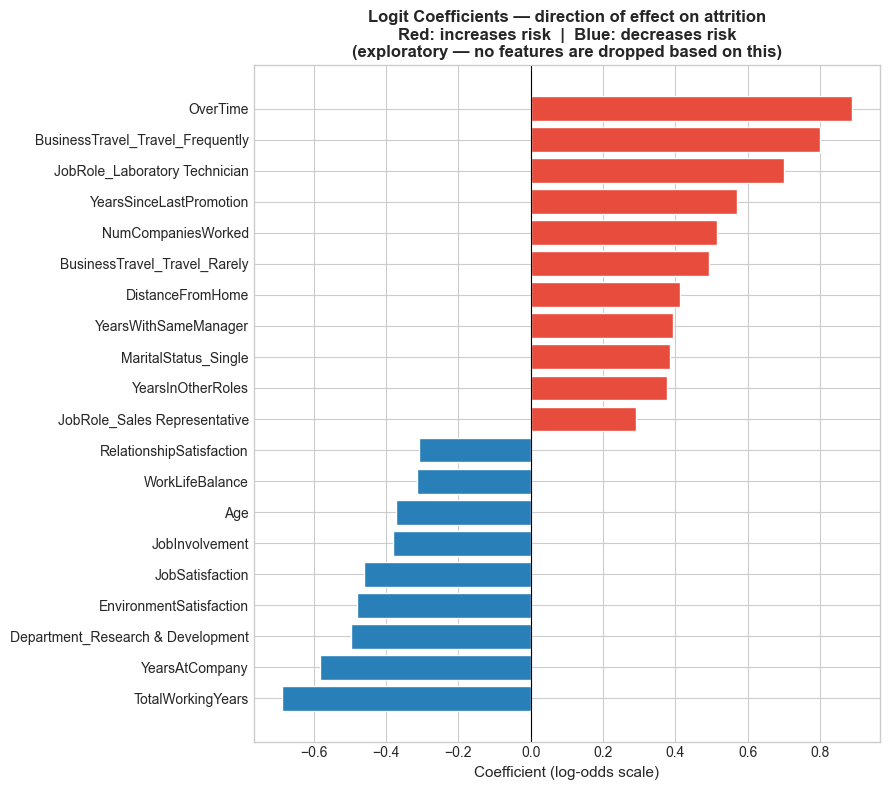

Note: 20/40 features show p < 0.05 in this linear model.
The coefficients help understand expected directions, not select features.


In [92]:


fig, ax = plt.subplots(figsize=(9, 8))
coefs_sign=coefs.loc[significant_features].sort_values()
bar_colors = ['#e74c3c' if v > 0 else '#2980b9' for v in coefs_sign.values]
ax.barh(coefs_sign.index, coefs_sign.values, color=bar_colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (log-odds scale)', fontsize=11)
ax.set_title('Logit Coefficients — direction of effect on attrition\n'
             'Red: increases risk  |  Blue: decreases risk\n'
             '(exploratory — no features are dropped based on this)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

sig = (pvals < 0.05).sum()
print(f"Note: {sig}/{len(pvals)} features show p < 0.05 in this linear model.")
print("The coefficients help understand expected directions, not select features.")

---
## Section 7 — Dimensionality Reduction (PCA)

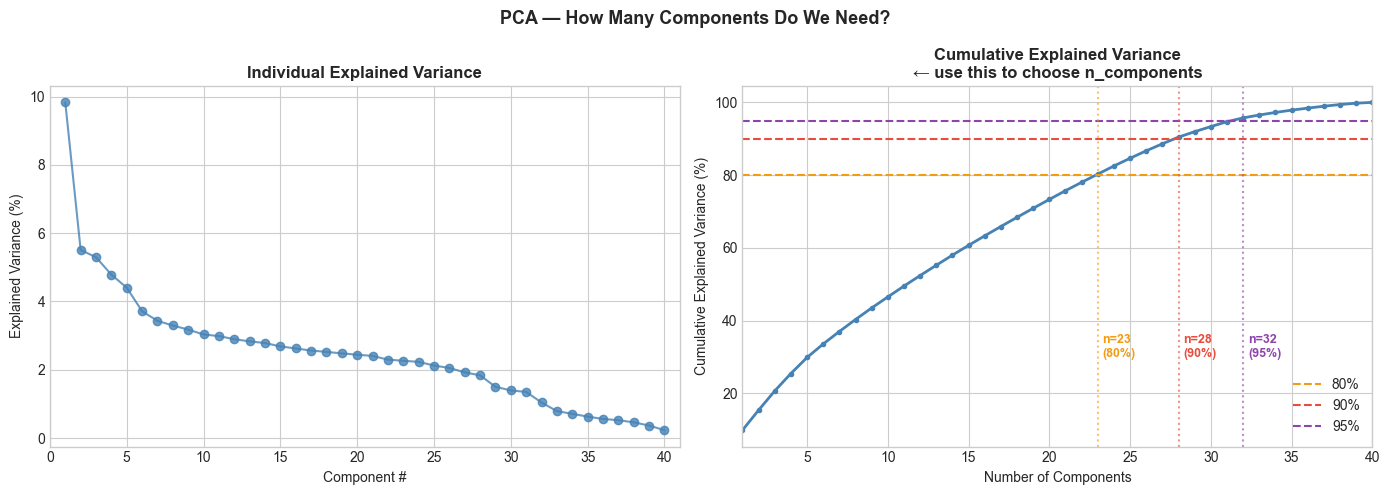


Components needed for 80% variance: 23
Components needed for 90% variance: 28
Components needed for 95% variance: 32
Total available features:           40


In [100]:
# First, fit PCA with ALL components to see the explained variance curve
pca_full = PCA(random_state=42)
pca_full.fit(X_train_sel)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_features = X_train_sel.shape[1]

# Find thresholds
n_80 = np.argmax(cumvar >= 0.80) + 1
n_90 = np.argmax(cumvar >= 0.90) + 1
n_95 = np.argmax(cumvar >= 0.95) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Individual variance
axes[0].plot(range(1, n_features + 1),
            pca_full.explained_variance_ratio_ * 100, marker='o',
            color='steelblue', alpha=0.8)
axes[0].set_xlabel('Component #')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Individual Explained Variance', fontweight='bold')
axes[0].set_xlim(0, min(40, n_features) + 1)

# Cumulative variance
x = range(1, n_features + 1)
axes[1].plot(x, cumvar * 100, 'o-', color='steelblue', linewidth=2, markersize=3)
axes[1].axhline(80, color='#f39c12', linestyle='--', linewidth=1.5, label='80%')
axes[1].axhline(90, color='#e74c3c', linestyle='--', linewidth=1.5, label='90%')
axes[1].axhline(95, color='#8e44ad', linestyle='--', linewidth=1.5, label='95%')
for n, c, lbl in [(n_80, '#f39c12', '80%'), (n_90, '#e74c3c', '90%'), (n_95, '#8e44ad', '95%')]:
    axes[1].axvline(n, color=c, linestyle=':', alpha=0.6)
    axes[1].text(n + 0.3, 30, f'n={n}\n({lbl})', color=c, fontsize=9, fontweight='bold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Explained Variance\n← use this to choose n_components', fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].set_xlim(1, min(40, n_features))

plt.suptitle('PCA — How Many Components Do We Need?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nComponents needed for 80% variance: {n_80}")
print(f"Components needed for 90% variance: {n_90}")
print(f"Components needed for 95% variance: {n_95}")
print(f"Total available features:           {n_features}")

---
## PARAM 3 — How Many PCA Components?

Looking at the cumulative explained variance plot:

**Questions:**
1. Is there an "elbow" in the curve? Where?
2. At how many components does the gain per component start to drop sharply?
3. If we were building a model for a bank with millions of transactions, would we care more or less about computational cost?

**Common rules of thumb:**
- Keep enough components to explain **80–90%** of variance
- Avoid keeping all components (defeats the purpose of PCA)
- Avoid too few (you lose important signal)


In [99]:
# ─── SET N_COMPONENTS — instructor updates after PARAM 3 ─────────────────────

N_COMPONENTS = 28    # <── CHANGE THIS based on class vote

# ─────────────────────────────────────────────────────────────────────────────
pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_train_pca = pca.fit_transform(X_train_sel)
X_test_pca  = pca.transform(X_test_sel)

retained = pca.explained_variance_ratio_.sum() * 100
print(f"PCA applied")
print(f"   Components: {N_COMPONENTS}")
print(f"   Variance retained: {retained:.1f}%")
print(f"   Dimensionality: {X_train_sel.shape[1]} → {X_train_pca.shape[1]}")

PCA applied
   Components: 28
   Variance retained: 90.4%
   Dimensionality: 40 → 28


---
## Section 8 — Classification

---
## PARAM 4 — Choose a Classifier

| Model | Interpretable? | Handles non-linearity? | Speed | Notes |
|-------|:-:|:-:|-------|-------|
| **Logistic Regression** | Yes | No (linear boundary) | Fast | Baseline; great for imbalanced if tuned |
| **Random Forest** | Partial | Yes | Medium | Robust, feature importance available |
| **SVM (RBF kernel)** | No | Yes | Slower | Strong on high-dim, hard to explain |

**Discussion:**
1. Our target audience is HR managers. Does interpretability matter?
2. After PCA, do we still have a "high-dimensional" problem?
3. Which model is least likely to overfit on a dataset of ~1200 training samples?


In [114]:
# ─── SET CLASSIFIER — instructor updates after PARAM 4 ───────────────────────

CLASSIFIER = 'svm'    # Options: 'logistic'  |  'random_forest'  |  'svm'

# ─────────────────────────────────────────────────────────────────────────────
classifiers = {
    'logistic':      LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    'random_forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    'svm':           SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
}

clf = classifiers[CLASSIFIER]
print(f"Classifier: {CLASSIFIER}")
print(f"   {clf}")

Classifier: svm
   SVC(class_weight='balanced', probability=True, random_state=42)


In [115]:
# ─── 5-FOLD STRATIFIED CROSS-VALIDATION ──────────────────────────────────────
# We evaluate on the TRAINING set with cross-validation.
# The test set is still untouched — it is our final, honest evaluation.
# ─────────────────────────────────────────────────────────────────────────────

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
cv_results = cross_validate(clf, X_train_pca, y_train, cv=cv,
                             scoring=scoring, return_train_score=False)

print("=" * 58)
print(f"   5-FOLD CROSS-VALIDATION  ·  {CLASSIFIER.upper()}")
print("=" * 58)
for metric in scoring:
    scores = cv_results[f'test_{metric}']
    bar = 'x' * int(scores.mean() * 20) + '-' * (20 - int(scores.mean() * 20))
    print(f"  {metric:<12} {bar}  {scores.mean():.3f} ± {scores.std():.3f}")
print("=" * 58)
print("\n  (± = standard deviation across 5 folds — lower is more stable)")


   5-FOLD CROSS-VALIDATION  ·  SVM
  accuracy     xxxxxxxxxxxxxxxx----  0.829 ± 0.016
  precision    xxxxxxxxx-----------  0.480 ± 0.039
  recall       xxxxxxxxxxx---------  0.595 ± 0.106
  f1           xxxxxxxxxx----------  0.526 ± 0.051
  roc_auc      xxxxxxxxxxxxxxxx----  0.810 ± 0.039

  (± = standard deviation across 5 folds — lower is more stable)


### VOTE - Without any additional information, what is currently the best metric for evaluating the model's performance?

---
## Section 9 — Final Evaluation on Test Set

In [116]:
# Train the final model on the full training set
clf.fit(X_train_pca, y_train)
y_pred = clf.predict(X_test_pca)
y_prob = clf.predict_proba(X_test_pca)[:, 1]

print("=" * 58)
print(f"   TEST SET RESULTS  ·  {CLASSIFIER.upper()}")
print("=" * 58)
print(classification_report(y_test, y_pred,
                             target_names=['No Attrition (0)', 'Attrition (1)']))


   TEST SET RESULTS  ·  SVM
                  precision    recall  f1-score   support

No Attrition (0)       0.92      0.88      0.90       247
   Attrition (1)       0.47      0.57      0.52        47

        accuracy                           0.83       294
       macro avg       0.69      0.73      0.71       294
    weighted avg       0.84      0.83      0.84       294



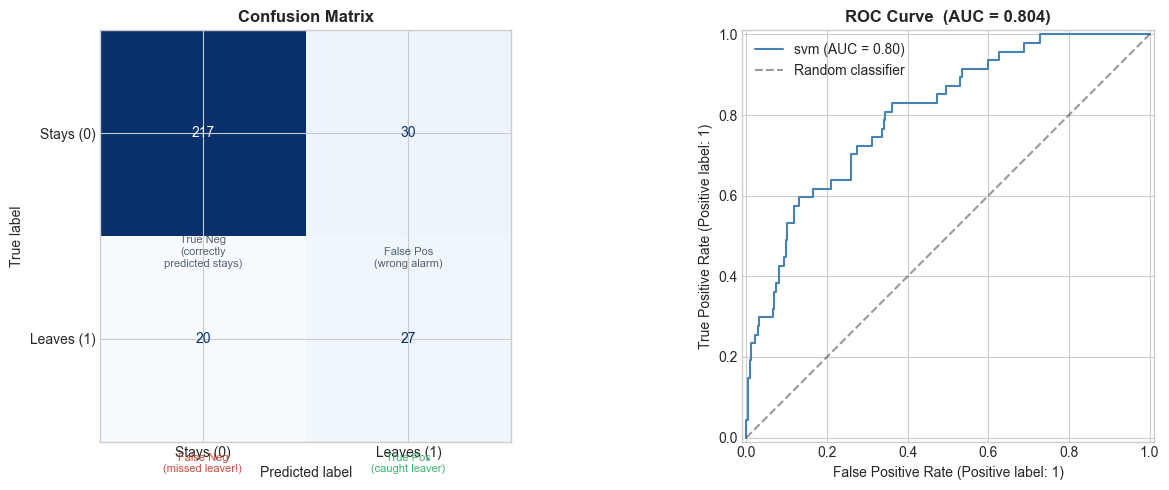


Breaking down the confusion matrix:
  True Positives  (leavers correctly caught):  27
  False Negatives (leavers we MISSED):         20  ← HR cares about this
  False Positives (wrong alarms):              30
  True Negatives  (stayers correctly ignored): 217


In [124]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Confusion Matrix ─────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Stays (0)', 'Leaves (1)'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')

# Annotate cells with explanations
tn, fp, fn, tp = cm.ravel()
axes[0].text(0, 0.65, f'True Neg\n(correctly\npredicted stays)', ha='center',
             fontsize=8, color='#2c3e50', alpha=0.8)
axes[0].text(1, 0.65, f'False Pos\n(wrong alarm)', ha='center',
             fontsize=8, color='#2c3e50', alpha=0.8)
axes[0].text(0, 1.65, f'False Neg\n(missed leaver!)', ha='center',
             fontsize=8, color='#c0392b', alpha=0.9)
axes[0].text(1, 1.65, f'True Pos\n(caught leaver)', ha='center',
             fontsize=8, color='#27ae60', alpha=0.9)

# ── ROC Curve ────────────────────────────────────────────────
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1], color='steelblue', name=CLASSIFIER)
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random classifier')
auc = roc_auc_score(y_test, y_prob)
axes[1].set_title(f'ROC Curve  (AUC = {auc:.3f})', fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nBreaking down the confusion matrix:")
print(f"  True Positives  (leavers correctly caught):  {tp}")
print(f"  False Negatives (leavers we MISSED):         {fn}  ← HR cares about this")
print(f"  False Positives (wrong alarms):              {fp}")
print(f"  True Negatives  (stayers correctly ignored): {tn}")


---
## Precision or Recall?

The model has a specific **Precision** and **Recall** for the "Attrition = Yes" class.

- **Precision** = Of all employees we flagged as "will leave", how many actually did?  
- **Recall** = Of all employees who actually left, how many did we catch?

In our context:
- A **False Negative** (missed leaver) = we do nothing, employee leaves → company pays replacement cost
- A **False Positive** (wrong alarm) = we trigger a retention program for someone who wasn't leaving → wasted effort, possible friction

**Questions:**
1. In general, which error is more costly for HR?
2. How does your answer change if the retention program is:
   - Very expensive (coaching, salary raise)?
   - Very cheap (a coffee chat with the manager)?
3. How do we operationally improve Recall without retraining? (hint: think about the threshold)

In [125]:
# ─── BONUS: Decision Threshold Tuning ────────────────────────────────────────
# Default threshold = 0.5  (predict "Yes" if P(attrition) >= 0.5)
# Lowering the threshold → more employees flagged → higher Recall, lower Precision
# ─────────────────────────────────────────────────────────────────────────────

print("Effect of threshold on Precision / Recall (Attrition class):")
print(f"{'Threshold':<12} {'Precision':>10} {'Recall':>8} {'F1':>8} {'Flagged':>10}")
print("-" * 52)

for thresh in [0.20, 0.25, 0.30, 0.35, 0.40, 0.50]:
    y_t = (y_prob >= thresh).astype(int)
    from sklearn.metrics import precision_score, recall_score, f1_score
    p = precision_score(y_test, y_t, zero_division=0)
    r = recall_score(y_test, y_t)
    f = f1_score(y_test, y_t)
    flagged = y_t.sum()
    print(f"  {thresh:<10} {p:>10.3f} {r:>8.3f} {f:>8.3f} {flagged:>10}")


Effect of threshold on Precision / Recall (Attrition class):
Threshold     Precision   Recall       F1    Flagged
----------------------------------------------------
  0.2             0.377    0.617    0.468         77
  0.25            0.474    0.574    0.519         57
  0.3             0.476    0.426    0.449         42
  0.35            0.486    0.362    0.415         35
  0.4             0.469    0.319    0.380         32
  0.5             0.688    0.234    0.349         16



=== With threshold = 0.4 ===
              precision    recall  f1-score   support

       Stays       0.88      0.93      0.90       247
      Leaves       0.47      0.32      0.38        47

    accuracy                           0.83       294
   macro avg       0.67      0.63      0.64       294
weighted avg       0.81      0.83      0.82       294



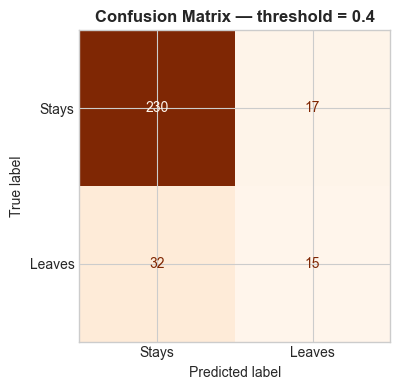

In [126]:
# ─── BONUS PARAM: pick a threshold and visualize ────────────────────────────

THRESHOLD = 0.4  # <── adjust this interactively in class

y_pred_t = (y_prob >= THRESHOLD).astype(int)

print(f"\n=== With threshold = {THRESHOLD} ===")
print(classification_report(y_test, y_pred_t, target_names=['Stays', 'Leaves']))

cm_t = confusion_matrix(y_test, y_pred_t)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_t, display_labels=['Stays', 'Leaves']).plot(ax=ax, cmap='Oranges', colorbar=False)
ax.set_title(f'Confusion Matrix — threshold = {THRESHOLD}', fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 10 — Hyperparameter Tuning & Final Model

The baseline model used default parameters. **GridSearchCV** systematically tries all parameter combinations and picks the best one using 5-fold cross-validation on the training set.

The key design decision: **what metric to optimize**. This connects directly to VOTE 5 — if you said recall matters more, you should optimize for recall, not accuracy.

---
## PARAM 5 — Scoring Metric for Tuning

The metric we optimize **must reflect the business priority** established in previous step.

| Option | Optimizes for | When to choose |
|--------|--------------|----------------|
| `'recall_class1'` | Catch as many leavers as possible | Missing a leaver is very costly |
| `'precision_class1'` | Minimize false positives | Wasted effort on retention programs |
| `'f1_class1'` | Balance precision/recall on leavers | Moderate cost on both error types |
| `'f1_macro'` | Average performance across both classes | Both classes matter equally |
| `'roc_auc'` | Overall ranking quality | Threshold will be tuned post-hoc |


In [145]:
from sklearn.metrics import make_scorer, recall_score, f1_score,precision_score
from sklearn.model_selection import GridSearchCV

# ─── PARAM 5: SET SCORING METRIC — instructor updates after vote ──────────────

SCORING_METRIC = 'roc_auc'
# Options: 'recall_class1' | 'f1_class1' | 'f1_macro' | 'roc_auc'

# ─────────────────────────────────────────────────────────────────────────────
scorer_map = {
    'recall_class1': make_scorer(recall_score, pos_label=1),
    'precision_class1': make_scorer(precision_score, pos_label=1),
    'f1_class1':     make_scorer(f1_score,     pos_label=1),
    'f1_macro':      'f1_macro',
    'roc_auc':       'roc_auc',
}

param_grids = {
    'logistic': {
        'C':      [0.01, 0.1, 1, 10, 100],
        'solver': ['lbfgs', 'liblinear'],
    },
    'random_forest': {
        'n_estimators':      [100, 200, 500],
        'max_depth':         [None, 5, 10],
        'min_samples_split': [2, 5, 10],
    },
    'svm': {
        'C':     [0.01,0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.01, 0.1,1],
    },
}

grid = GridSearchCV(
    classifiers[CLASSIFIER],
    param_grids[CLASSIFIER],
    scoring=scorer_map[SCORING_METRIC],
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    refit=True,
)
grid.fit(X_train_pca, y_train)

print(f"Scoring metric : {SCORING_METRIC}")
print(f"Best params    : {grid.best_params_}")
print(f"Best CV score  : {grid.best_score_:.4f}")

Scoring metric : roc_auc
Best params    : {'C': 1, 'gamma': 0.01}
Best CV score  : 0.8296


In [146]:
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score

best_clf    = grid.best_estimator_
y_pred_tuned = best_clf.predict(X_test_pca)
y_prob_tuned = best_clf.predict_proba(X_test_pca)[:, 1]

metrics_fns = {
    'Accuracy':      lambda yt, yp, ypr: accuracy_score(yt, yp),
    'Recall (cl.1)': lambda yt, yp, ypr: recall_score(yt, yp),
    'F1 (class 1)':  lambda yt, yp, ypr: f1_score(yt, yp),
    'F1 macro':      lambda yt, yp, ypr: f1_score(yt, yp, average='macro'),
    'ROC AUC':       lambda yt, yp, ypr: roc_auc_score(yt, ypr),
}

print("=" * 62)
print(f"   BASELINE  vs  TUNED   [{CLASSIFIER.upper()}]")
print(f"   Optimization metric: {SCORING_METRIC}")
print("=" * 62)
print(f"  {'Metric':<16} {'Baseline':>10}  {'Tuned':>10}  {'Delta':>8}")
print("  " + "-" * 48)

for name, fn in metrics_fns.items():
    base_val  = fn(y_test, y_pred,       y_prob)
    tuned_val = fn(y_test, y_pred_tuned, y_prob_tuned)
    delta = tuned_val - base_val
    arrow = 'up' if delta > 0.001 else ('dn' if delta < -0.001 else '--')
    print(f"  {name:<16} {base_val:>10.4f}  {tuned_val:>10.4f}  {arrow} {abs(delta):.4f}")

print("=" * 62)
print(f"\nBest CV score ({SCORING_METRIC}): {grid.best_score_:.4f}")
print(f"Best params: {grid.best_params_}")

   BASELINE  vs  TUNED   [SVM]
   Optimization metric: roc_auc
  Metric             Baseline       Tuned     Delta
  ------------------------------------------------
  Accuracy             0.8299      0.7891  dn 0.0408
  Recall (cl.1)        0.5745      0.5957  up 0.0213
  F1 (class 1)         0.5192      0.4746  dn 0.0447
  F1 macro             0.7080      0.6713  dn 0.0366
  ROC AUC              0.8036      0.8218  up 0.0182

Best CV score (roc_auc): 0.8296
Best params: {'C': 1, 'gamma': 0.01}


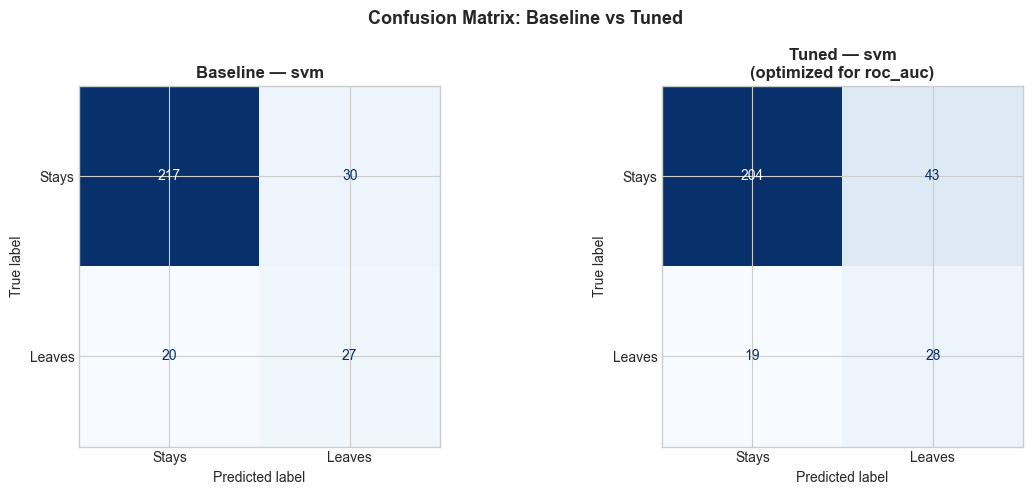

In [147]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_p, title in [
    (axes[0], y_pred,       f'Baseline — {CLASSIFIER}'),
    (axes[1], y_pred_tuned, f'Tuned — {CLASSIFIER}\n(optimized for {SCORING_METRIC})'),
]:
    cm_plot = confusion_matrix(y_test, y_p)
    ConfusionMatrixDisplay(cm_plot, display_labels=['Stays', 'Leaves']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontweight='bold')

plt.suptitle('Confusion Matrix: Baseline vs Tuned', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Session Wrap-up

### What we built today

```
Raw Data (1470 × 35)
   │
   ├─ [EDA]          → dropped 4 zero-variance / ID columns
   ├─ [Imputation]   → PARAM 1: mean / median / mode per column type
   ├─ [Split]        → 80/20 stratified (BEFORE encoding and scaling!)
   ├─ [OHE]          → OneHotEncoder fitted on train, applied to both
   ├─ [Standardize]  → StandardScaler fitted on train only
   ├─ [Correlation]  → PARAM 2: removed features above threshold
   ├─ [VIF]          → multicollinearity diagnostics (no selection)
   ├─ [Logit]        → direction of effects (exploratory only)
   ├─ [PCA]          → PARAM 3 components (~X% variance retained)
   ├─ [CV]           → 5-fold stratified cross-validation
   ├─ [Evaluate]     → confusion matrix, ROC, precision/recall
   └─ [Tuning]       → GridSearchCV with PARAM 5 metric → final model
```

---

### Every Decision We Made — and Why It Matters

| Decision | Chosen value | If we had chosen differently |
|----------|-------------|------------------------------|
| Drop useless columns | EmployeeCount, StandardHours, Over18, EmployeeNumber | Model trains on noise; no practical harm here but bad habit |
| Imputation strategy | PARAM 1 | Mean on skewed income → biased fill values → distorted distributions |
| Split before encoding & scaling | Yes | Encoding/scaling before split = data leakage from test into train |
| OHE with drop_first | Yes | Without it: perfect multicollinearity breaks logistic regression |
| Correlation threshold | PARAM 2 | Too lenient = keep redundant features; too strict = lose useful signal |
| PCA n_components | PARAM 3 | Too few = info loss; too many = defeats dimensionality reduction |
| Classifier | PARAM 4 | Context-dependent: speed vs accuracy vs interpretability |
| Tuning metric | PARAM 5 | Optimizing accuracy on imbalanced data → model ignores the minority class |
| Decision threshold | (bonus) | Operationally shifts precision/recall trade-off without retraining |

---

### Topics to Explore Next

- **Handling imbalanced classes** — SMOTE, class weighting, undersampling
- **Feature importance** — from Random Forest (post-hoc, without p-values)
- **SHAP values** — model-agnostic interpretability for any black-box classifier
- **Pipeline objects** — `sklearn.Pipeline` to chain all steps cleanly and prevent leakage by construction

---

*All decisions made in this session are stored in variables — change any PARAM and re-run from that point to see how results change.*